# 4. Glamsterdam shared-fee equilibrium

This notebook combines:

- the February–May 2026 historical anchor and metering multipliers from notebook 02; and
- the four linked elasticity vectors from notebook 03.

For each gas limit, it solves the static fixed point where the larger of regular metered gas (execution plus data) and EIP-8037 state gas equals half the gas limit. It also reproduces the effective-price ranges and state-demand-tail diagnostics in the report.

Notebooks 01–03 must be run first.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from demand import Anchor, DemandParams, FeeDimension, WorldSpec, solve_equilibrium

OUT_DIR = PROJECT_ROOT / "data" / "glamsterdam"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

ANCHOR_INPUT = OUT_DIR / "equilibrium_anchor.csv"
ELASTICITY_INPUT = OUT_DIR / "elasticity_vectors.csv"

RESULTS_OUT = OUT_DIR / "equilibrium_results.csv"
WINDOW_OUT = OUT_DIR / "equilibrium_window_sensitivity.csv"
HEADLINE_OUT = OUT_DIR / "equilibrium_headline.csv"
PRICE_OUT = OUT_DIR / "effective_price_ranges.csv"
STATE_CAP_OUT = OUT_DIR / "state_cap_sensitivity.csv"
STATE_CAP_SWEEP_OUT = OUT_DIR / "state_cap_sweep.csv"

FEE_PLOT = PLOTS_DIR / "three_way_equilibrium_gas_limit_curves_2026-02-01_2026-06-01.png"
PRICE_PLOT = PLOTS_DIR / "glamsterdam_effective_price_ratios_2026-02-01_2026-06-01.png"
CAP_PLOT = PLOTS_DIR / "glamsterdam_state_cap_branch_regimes_2026-02-01_2026-06-01.png"

for required in [ANCHOR_INPUT, ELASTICITY_INPUT]:
    if not required.exists():
        raise FileNotFoundError(f"Missing {required}. Run notebooks 01–03 first.")

anchor_row = pd.read_csv(ANCHOR_INPUT).iloc[0]
elasticity_vectors = pd.read_csv(ELASTICITY_INPUT)

RESOURCES = ["execution", "data", "state"]
WINDOWS = [21, 35, 60, 75]
GAS_LIMITS = [
    60_000_000,
    100_000_000,
    150_000_000,
    200_000_000,
    250_000_000,
    300_000_000,
]
GWEI = 1e9

ANCHOR_QUANTITIES = {
    resource: float(anchor_row[f"q_{resource}_per_block"])
    for resource in RESOURCES
}
METERING = {
    resource: float(anchor_row[f"m_{resource}"])
    for resource in RESOURCES
}
BASE_FEE_REF = float(anchor_row["base_fee_ref_wei"])

assert elasticity_vectors["window_days"].tolist() == WINDOWS
ANCHOR_QUANTITIES, METERING, BASE_FEE_REF / GWEI

({'execution': 23942241.363434453,
  'data': 1180555.063054834,
  'state': 5244154.703798162},
 {'execution': 1.5378980217571416,
  'data': 1.968761648325156,
  'state': 5.656315259465248},
 0.1069278435)

## Independent demand system and solver

A trial shared fee is multiplied by each resource's metering multiplier to obtain its effective resource price. Demand responds to that price, is remetered under Glamsterdam, and the solver adjusts the shared fee until the larger branch reaches the target.

In [2]:
def make_independent_demand(eps, state_cap_multiple=None):
    def demand(price_ratios):
        quantities = {
            resource: ANCHOR_QUANTITIES[resource]
            * price_ratios[resource] ** (-eps[resource])
            for resource in RESOURCES
        }
        if state_cap_multiple is not None:
            quantities["state"] = min(
                quantities["state"],
                state_cap_multiple * ANCHOR_QUANTITIES["state"],
            )
        return quantities

    return demand


def solve_glamsterdam(vector, gas_limit, state_cap_multiple=None):
    eps = {
        resource: float(vector[f"eps_{resource}"])
        for resource in RESOURCES
    }
    demand_fn = make_independent_demand(
        eps,
        state_cap_multiple=state_cap_multiple,
    )
    demand_anchor = Anchor(
        quantities=dict(ANCHOR_QUANTITIES),
        effective_prices={resource: BASE_FEE_REF for resource in RESOURCES},
    )
    world = WorldSpec(
        name="glamsterdam_shared_8037",
        multipliers=dict(METERING),
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=float(gas_limit) / 2,
            ),
        ),
    )
    informational_params = DemandParams(
        eps_agg=float(vector["eps_agg"]),
        eta_state=0.0,
        eta_data=0.0,
    )
    equilibrium = solve_equilibrium(
        demand_anchor,
        informational_params,
        world,
        demand_fn=demand_fn,
    )

    regular_gas = (
        equilibrium.quantities["execution"] * METERING["execution"]
        + equilibrium.quantities["data"] * METERING["data"]
    )
    state_gas = equilibrium.quantities["state"] * METERING["state"]
    fee_wei = equilibrium.prices_wei["regular_state"]

    return {
        "window_days": int(vector["window_days"]),
        "eps_agg": float(vector["eps_agg"]),
        "eps_execution": eps["execution"],
        "eps_data": eps["data"],
        "eps_state": eps["state"],
        "gas_limit": gas_limit,
        "gas_target": gas_limit / 2,
        "demand_variant": (
            "uncapped_isoelastic"
            if state_cap_multiple is None
            else f"state_cap_{state_cap_multiple:g}x"
        ),
        "state_cap_multiple": state_cap_multiple,
        "state_cap_binding": bool(
            state_cap_multiple is not None
            and np.isclose(
                equilibrium.quantities["state"],
                state_cap_multiple * ANCHOR_QUANTITIES["state"],
            )
        ),
        "equilibrium_base_fee_gwei": fee_wei / GWEI,
        "base_fee_ratio_to_anchor": fee_wei / BASE_FEE_REF,
        "quantity_execution": equilibrium.quantities["execution"],
        "quantity_data": equilibrium.quantities["data"],
        "quantity_state": equilibrium.quantities["state"],
        "regular_metered_gas": regular_gas,
        "state_metered_gas": state_gas,
        "binding_branch": "state" if state_gas >= regular_gas else "regular",
        "floor_binding": equilibrium.floor_binding["regular_state"],
        "target_unreachable": equilibrium.target_unreachable["regular_state"],
        "converged": equilibrium.converged,
    }

## Uncapped isoelastic benchmark

In [3]:
rows = [
    solve_glamsterdam(vector, gas_limit)
    for _, vector in elasticity_vectors.iterrows()
    for gas_limit in GAS_LIMITS
]
results = pd.DataFrame(rows)
results.to_csv(RESULTS_OUT, index=False)

assert results["converged"].all()
assert not results["target_unreachable"].any()

target_gap = (
    results[["regular_metered_gas", "state_metered_gas"]].max(axis=1)
    - results["gas_target"]
).abs()
assert (target_gap < 1).all()

window_sensitivity = results.copy()
window_sensitivity["gas_limit_M"] = window_sensitivity["gas_limit"] / 1e6
window_sensitivity["gas_target_M"] = window_sensitivity["gas_target"] / 1e6
for resource in RESOURCES:
    window_sensitivity[f"quantity_{resource}_M"] = (
        window_sensitivity[f"quantity_{resource}"] / 1e6
    )
    window_sensitivity[f"effective_price_ratio_{resource}"] = (
        METERING[resource] * window_sensitivity["base_fee_ratio_to_anchor"]
    )
window_sensitivity["regular_metered_gas_M"] = (
    window_sensitivity["regular_metered_gas"] / 1e6
)
window_sensitivity["state_metered_gas_M"] = (
    window_sensitivity["state_metered_gas"] / 1e6
)
window_sensitivity.to_csv(WINDOW_OUT, index=False)

headline = (
    window_sensitivity.groupby(["gas_limit_M", "gas_target_M"], as_index=False)
    .agg(
        equilibrium_fee_min_gwei=("equilibrium_base_fee_gwei", "min"),
        equilibrium_fee_max_gwei=("equilibrium_base_fee_gwei", "max"),
        regular_metered_gas_min_M=("regular_metered_gas_M", "min"),
        regular_metered_gas_max_M=("regular_metered_gas_M", "max"),
        state_metered_gas_min_M=("state_metered_gas_M", "min"),
        state_metered_gas_max_M=("state_metered_gas_M", "max"),
        binding_branch=("binding_branch", lambda values: ", ".join(sorted(set(values)))),
        window_count=("window_days", "nunique"),
    )
)
headline.to_csv(HEADLINE_OUT, index=False)
headline

,gas_limit_M,gas_target_M,equilibrium_fee_min_gwei,equilibrium_fee_max_gwei,regular_metered_gas_min_M,regular_metered_gas_max_M,state_metered_gas_min_M,state_metered_gas_max_M,binding_branch,window_count
0,60.000000,30.000000,0.553747,1.575098,30.000000,30.000000,5.641813,9.664769,regular,4
1,100.000000,50.000000,0.004004,0.009999,50.000000,50.000000,36.713911,44.543810,regular,4
2,150.000000,75.000000,0.000487,0.002720,58.064716,65.900160,75.000000,75.000000,state,4
3,200.000000,100.000000,0.000157,0.001491,62.537757,73.734423,100.000000,100.000000,state,4
4,250.000000,125.000000,0.000065,0.000935,66.251646,80.487027,125.000000,125.000000,state,4
5,300.000000,150.000000,0.000032,0.000639,69.455142,86.490485,150.000000,150.000000,state,4


## Effective resource prices and state extrapolation

The effective price of a historical gas-equivalent unit is the shared fee multiplied by the resource's metering multiplier. When state binds, its implied historical activity is the target divided by the state multiplier.

In [4]:
effective_price_ranges = (
    window_sensitivity.groupby(["gas_limit_M", "gas_target_M"], as_index=False)
    .agg(
        base_fee_ratio_min=("base_fee_ratio_to_anchor", "min"),
        base_fee_ratio_max=("base_fee_ratio_to_anchor", "max"),
        execution_ratio_min=("effective_price_ratio_execution", "min"),
        execution_ratio_max=("effective_price_ratio_execution", "max"),
        data_ratio_min=("effective_price_ratio_data", "min"),
        data_ratio_max=("effective_price_ratio_data", "max"),
        state_ratio_min=("effective_price_ratio_state", "min"),
        state_ratio_max=("effective_price_ratio_state", "max"),
    )
)
effective_price_ranges.to_csv(PRICE_OUT, index=False)

state_extrapolation = pd.DataFrame([
    {
        "gas_limit_M": gas_limit / 1e6,
        "state_target_M": gas_limit / 2e6,
        "implied_state_activity_M": gas_limit / 2 / METERING["state"] / 1e6,
        "multiple_of_anchor": (
            gas_limit / 2 / METERING["state"] / ANCHOR_QUANTITIES["state"]
        ),
    }
    for gas_limit in GAS_LIMITS
    if gas_limit >= 150_000_000
])

display(effective_price_ranges)
state_extrapolation

,gas_limit_M,gas_target_M,base_fee_ratio_min,base_fee_ratio_max,execution_ratio_min,execution_ratio_max,data_ratio_min,data_ratio_max,state_ratio_min,state_ratio_max
0,60.000000,30.000000,5.178695,14.730478,7.964305,22.653972,10.195617,29.000799,29.292334,83.320225
1,100.000000,50.000000,0.037443,0.093513,0.057583,0.143813,0.073716,0.184105,0.211789,0.528939
2,150.000000,75.000000,0.004557,0.025436,0.007008,0.039118,0.008971,0.050078,0.025774,0.143875
3,200.000000,100.000000,0.001465,0.013942,0.002253,0.021441,0.002885,0.027448,0.008288,0.078858
4,250.000000,125.000000,0.000608,0.008745,0.000935,0.013449,0.001196,0.017217,0.003437,0.049464
5,300.000000,150.000000,0.000296,0.005974,0.000455,0.009187,0.000583,0.011761,0.001675,0.033790


,gas_limit_M,state_target_M,implied_state_activity_M,multiple_of_anchor
0,150.000000,75.000000,13.259516,2.528437
1,200.000000,100.000000,17.679354,3.371250
2,250.000000,125.000000,22.099193,4.214062
3,300.000000,150.000000,26.519031,5.056874


## Shared-fee and binding-branch figure

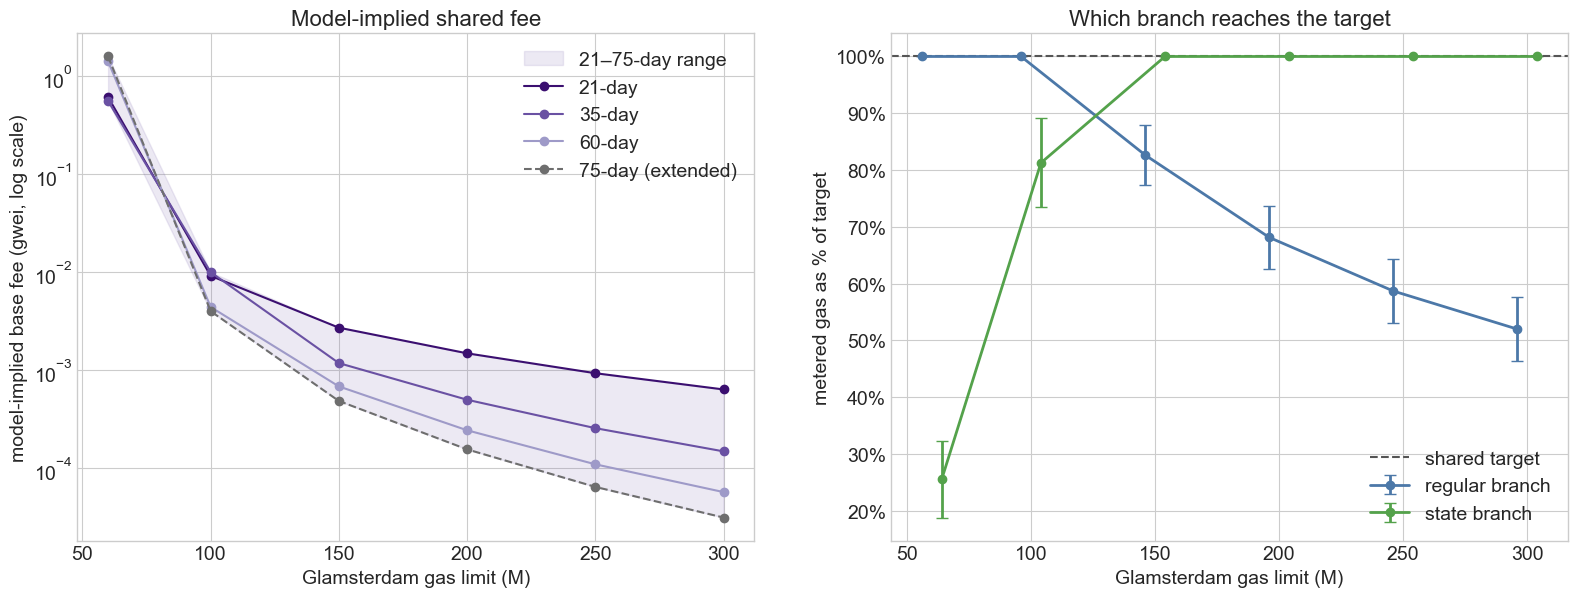

Wrote plots/three_way_equilibrium_gas_limit_curves_2026-02-01_2026-06-01.png


In [5]:
fee_window = results.pivot(
    index="gas_limit",
    columns="window_days",
    values="equilibrium_base_fee_gwei",
).sort_index()
regular_utilization = (
    results.assign(
        target_utilization=results["regular_metered_gas"] / results["gas_target"]
    )
    .pivot(index="gas_limit", columns="window_days", values="target_utilization")
    .sort_index()
)
state_utilization = (
    results.assign(
        target_utilization=results["state_metered_gas"] / results["gas_target"]
    )
    .pivot(index="gas_limit", columns="window_days", values="target_utilization")
    .sort_index()
)

x = fee_window.index.to_numpy() / 1e6
window_colors = {
    21: "#3B0F70",
    35: "#6A51A3",
    60: "#9E9AC8",
    75: "#6E6E6E",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))
axes[0].fill_between(
    x,
    fee_window.min(axis=1).to_numpy(),
    fee_window.max(axis=1).to_numpy(),
    alpha=0.12,
    color="#6A51A3",
    label="21–75-day range",
)
for window in WINDOWS:
    suffix = " (extended)" if window == 75 else ""
    axes[0].plot(
        x,
        fee_window[window],
        marker="o",
        linestyle="--" if window == 75 else "-",
        color=window_colors[window],
        label=f"{window}-day{suffix}",
    )
axes[0].set_xlabel("Glamsterdam gas limit (M)")
axes[0].set_ylabel("model-implied base fee (gwei, log scale)")
axes[0].set_yscale("log")
axes[0].set_title("Model-implied shared fee")
axes[0].legend()

for utilization, color, label, offset in [
    (regular_utilization, "#4C78A8", "regular branch", -4),
    (state_utilization, "#54A24B", "state branch", 4),
]:
    lower = 100 * utilization.min(axis=1).to_numpy()
    upper = 100 * utilization.max(axis=1).to_numpy()
    midpoint = (lower + upper) / 2
    axes[1].errorbar(
        x + offset,
        midpoint,
        yerr=[midpoint - lower, upper - midpoint],
        marker="o",
        capsize=4,
        linewidth=2,
        color=color,
        label=label,
    )
axes[1].axhline(
    100,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    label="shared target",
)
axes[1].set_xlabel("Glamsterdam gas limit (M)")
axes[1].set_ylabel("metered gas as % of target")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1].set_title("Which branch reaches the target")
axes[1].legend()

fig.tight_layout(w_pad=3)
fig.savefig(FEE_PLOT, dpi=180)
plt.show()

print(f"Wrote {FEE_PLOT.relative_to(PROJECT_ROOT)}")

## Effective-price figure

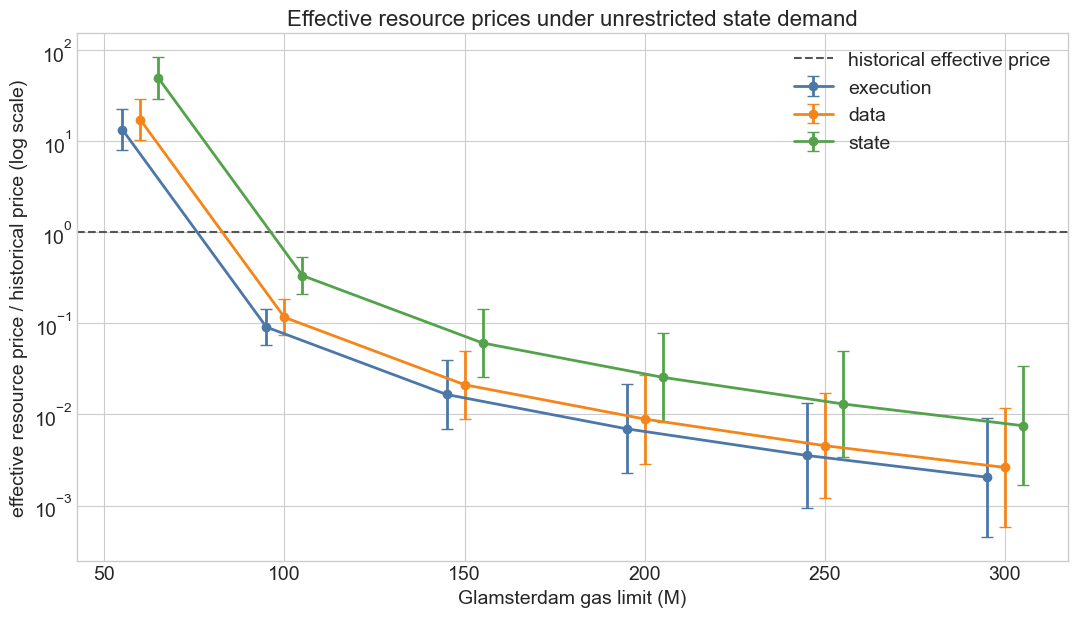

Wrote plots/glamsterdam_effective_price_ratios_2026-02-01_2026-06-01.png


In [6]:
fig, axis = plt.subplots(figsize=(11, 6.4))
x_price = effective_price_ranges["gas_limit_M"].to_numpy()

for resource, color, label, offset in [
    ("execution", "#4C78A8", "execution", -5),
    ("data", "#F58518", "data", 0),
    ("state", "#54A24B", "state", 5),
]:
    lower = effective_price_ranges[f"{resource}_ratio_min"].to_numpy()
    upper = effective_price_ranges[f"{resource}_ratio_max"].to_numpy()
    midpoint = np.sqrt(lower * upper)
    axis.errorbar(
        x_price + offset,
        midpoint,
        yerr=[midpoint - lower, upper - midpoint],
        marker="o",
        capsize=4,
        linewidth=2,
        color=color,
        label=label,
    )

axis.axhline(
    1,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    label="historical effective price",
)
axis.set_xlabel("Glamsterdam gas limit (M)")
axis.set_ylabel("effective resource price / historical price (log scale)")
axis.set_yscale("log")
axis.set_title("Effective resource prices under unrestricted state demand")
axis.legend()

fig.tight_layout()
fig.savefig(PRICE_PLOT, dpi=180)
plt.show()

print(f"Wrote {PRICE_PLOT.relative_to(PROJECT_ROOT)}")

## State-demand saturation diagnostic

The cap is a diagnostic assumption rather than an estimate. The full sweep maps which branch determines the shared fee when state activity is capped at two, three, four, or five times its historical anchor.

In [7]:
CAP_MULTIPLES = [2.0, 3.0, 4.0, 5.0, None]
cap_rows = [
    solve_glamsterdam(vector, gas_limit, state_cap_multiple)
    for state_cap_multiple in CAP_MULTIPLES
    for _, vector in elasticity_vectors.iterrows()
    for gas_limit in GAS_LIMITS
]
cap_results = pd.DataFrame(cap_rows)
cap_results["gas_limit_M"] = cap_results["gas_limit"] / 1e6
cap_results["gas_target_M"] = cap_results["gas_target"] / 1e6
cap_results["cap_label"] = cap_results["state_cap_multiple"].map(
    lambda value: "unrestricted (∞)" if pd.isna(value) else f"{value:g}×"
)
cap_results.to_csv(STATE_CAP_SWEEP_OUT, index=False)

cap_2x = cap_results[np.isclose(cap_results["state_cap_multiple"].fillna(-1), 2.0)].copy()
uncapped_fees = window_sensitivity[
    ["gas_limit_M", "window_days", "equilibrium_base_fee_gwei"]
].rename(columns={"equilibrium_base_fee_gwei": "uncapped_base_fee_gwei"})
cap_2x = cap_2x.merge(
    uncapped_fees,
    on=["gas_limit_M", "window_days"],
    how="left",
    validate="one_to_one",
)
cap_2x["capped_fee_pct_of_uncapped"] = (
    100
    * cap_2x["equilibrium_base_fee_gwei"]
    / cap_2x["uncapped_base_fee_gwei"]
)
cap_2x.to_csv(STATE_CAP_OUT, index=False)

branch_counts = cap_results.groupby(
    ["cap_label", "gas_limit_M"]
)["binding_branch"].nunique()
assert branch_counts.eq(1).all()

cap_order = ["2×", "3×", "4×", "5×", "unrestricted (∞)"]
branch_matrix = (
    cap_results.groupby(["cap_label", "gas_limit_M"])["binding_branch"]
    .first()
    .unstack("gas_limit_M")
    .reindex(index=cap_order, columns=np.array(GAS_LIMITS) / 1e6)
)
branch_matrix

gas_limit_M,60.000000,100.000000,150.000000,200.000000,250.000000,300.000000
cap_label,,,,,,
2×,regular,regular,regular,regular,regular,regular
3×,regular,regular,state,regular,regular,regular
4×,regular,regular,state,state,regular,regular
5×,regular,regular,state,state,state,regular
unrestricted (∞),regular,regular,state,state,state,state


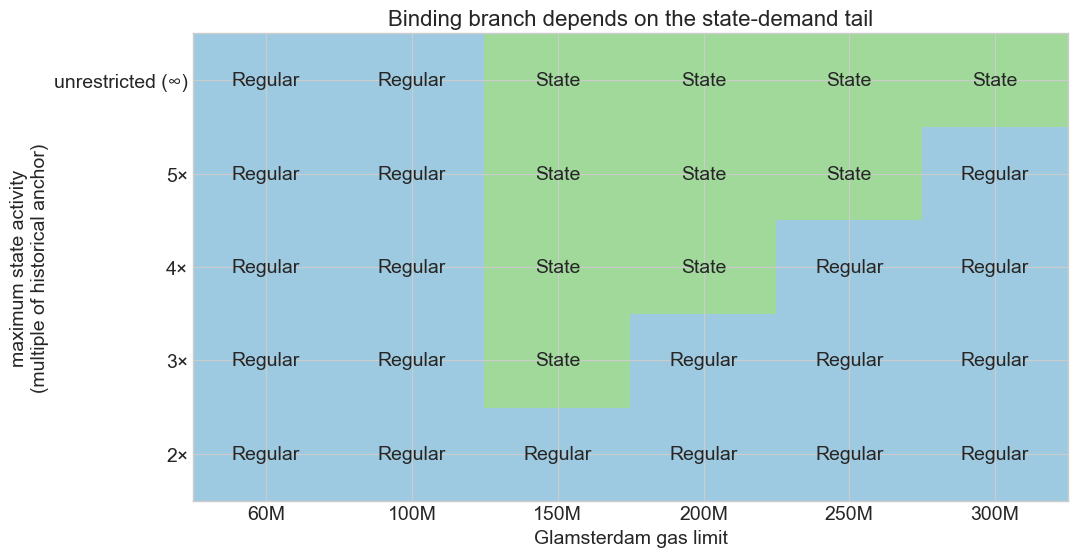

Wrote plots/glamsterdam_state_cap_branch_regimes_2026-02-01_2026-06-01.png


In [8]:
branch_codes = branch_matrix.apply(
    lambda column: column.map({"regular": 0, "state": 1})
)

fig, axis = plt.subplots(figsize=(11, 5.8))
axis.imshow(
    branch_codes.to_numpy(),
    origin="lower",
    aspect="auto",
    cmap=ListedColormap(["#9ECAE1", "#A1D99B"]),
    vmin=-0.5,
    vmax=1.5,
)
axis.set_xticks(
    np.arange(branch_matrix.shape[1]),
    [f"{value:g}M" for value in branch_matrix.columns],
)
axis.set_yticks(np.arange(branch_matrix.shape[0]), branch_matrix.index)
for row in range(branch_matrix.shape[0]):
    for column in range(branch_matrix.shape[1]):
        axis.text(
            column,
            row,
            branch_matrix.iloc[row, column].title(),
            ha="center",
            va="center",
            fontsize=14,
        )
axis.set_xlabel("Glamsterdam gas limit")
axis.set_ylabel("maximum state activity\n(multiple of historical anchor)")
axis.set_title("Binding branch depends on the state-demand tail")

fig.tight_layout()
fig.savefig(CAP_PLOT, dpi=180)
plt.show()

print(f"Wrote {CAP_PLOT.relative_to(PROJECT_ROOT)}")

## Numerical validation

These assertions compare the computed, unrounded outputs with the headline ranges and branch classifications reported in `markdowns/demand_model_and_glamsterdam_analysis.md`.

In [9]:
expected_fee_ranges = {
    60.0: (0.553747, 1.575098),
    100.0: (0.004004, 0.009999),
    150.0: (0.000487, 0.002720),
    200.0: (0.000157, 0.001491),
    250.0: (0.000065, 0.000935),
    300.0: (0.000032, 0.000639),
}
for gas_limit_M, (expected_min, expected_max) in expected_fee_ranges.items():
    row = headline.loc[headline["gas_limit_M"].eq(gas_limit_M)].iloc[0]
    assert np.isclose(
        row["equilibrium_fee_min_gwei"],
        expected_min,
        rtol=0,
        atol=5e-7,
    )
    assert np.isclose(
        row["equilibrium_fee_max_gwei"],
        expected_max,
        rtol=0,
        atol=5e-7,
    )

expected_branch_matrix = pd.DataFrame(
    [
        ["regular", "regular", "regular", "regular", "regular", "regular"],
        ["regular", "regular", "state", "regular", "regular", "regular"],
        ["regular", "regular", "state", "state", "regular", "regular"],
        ["regular", "regular", "state", "state", "state", "regular"],
        ["regular", "regular", "state", "state", "state", "state"],
    ],
    index=cap_order,
    columns=np.array(GAS_LIMITS) / 1e6,
)
assert branch_matrix.equals(expected_branch_matrix)
assert not cap_results["target_unreachable"].any()
assert cap_results["converged"].all()

headline

,gas_limit_M,gas_target_M,equilibrium_fee_min_gwei,equilibrium_fee_max_gwei,regular_metered_gas_min_M,regular_metered_gas_max_M,state_metered_gas_min_M,state_metered_gas_max_M,binding_branch,window_count
0,60.000000,30.000000,0.553747,1.575098,30.000000,30.000000,5.641813,9.664769,regular,4
1,100.000000,50.000000,0.004004,0.009999,50.000000,50.000000,36.713911,44.543810,regular,4
2,150.000000,75.000000,0.000487,0.002720,58.064716,65.900160,75.000000,75.000000,state,4
3,200.000000,100.000000,0.000157,0.001491,62.537757,73.734423,100.000000,100.000000,state,4
4,250.000000,125.000000,0.000065,0.000935,66.251646,80.487027,125.000000,125.000000,state,4
5,300.000000,150.000000,0.000032,0.000639,69.455142,86.490485,150.000000,150.000000,state,4
